In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.precision', 3)

In [2]:
# Extra imports
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox, norm
from statsmodels.genmod.generalized_linear_model import GLM

In [3]:
import warnings
warnings.filterwarnings('ignore')

# 1. Analyzing the dataset

[YAPPING]

In [4]:
raw_data = read_csv("train_features_ILDS.csv", delimiter = ',', header = None)
raw_data.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 
                    'Sgot', 'TP', 'ALB', 'AR']
raw_data['Target'] = read_csv("train_labels_ILDS.csv", delimiter=',', header = None)
raw_data['Female'] = raw_data['Female'].astype('category')
raw_data['Target'] = raw_data['Target'].astype('category')

raw_data.shape #tamany

(463, 11)

In [5]:
raw_data.head()

,Age,Female,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,Target
0,40,0,3.9,1.7,350,950,1500,6.7,3.8,1.30,0
1,48,0,4.5,2.3,282,13,74,7.0,2.4,0.52,0
2,39,0,1.9,0.9,180,42,62,7.4,4.3,1.38,0
3,23,0,1.0,0.3,212,41,80,6.2,3.1,1.00,0
4,42,1,0.7,0.2,152,35,81,6.2,3.2,1.06,0


In [6]:
raw_data.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR
count,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000,463.000
mean,44.881,3.279,1.446,279.866,75.844,97.607,6.422,3.110,0.943
std,16.309,6.115,2.675,211.283,169.290,212.114,1.052,0.793,0.318
min,4.000,0.400,0.100,75.000,10.000,11.000,2.700,0.900,0.300
25%,33.000,0.800,0.200,176.000,23.000,25.000,5.700,2.500,0.700
50%,45.000,1.000,0.300,208.000,34.000,41.000,6.500,3.100,0.920
75%,57.500,2.700,1.300,291.000,60.000,83.500,7.100,3.700,1.100
max,90.000,75.000,18.300,1630.000,2000.000,2946.000,9.500,5.500,2.800


In [7]:
print(raw_data[raw_data['Female'] == 1]['Target'].value_counts())
print(raw_data[raw_data['Female'] == 0]['Target'].value_counts())

Target
0    74
1    38
Name: count, dtype: int64
Target
0    257
1     94
Name: count, dtype: int64


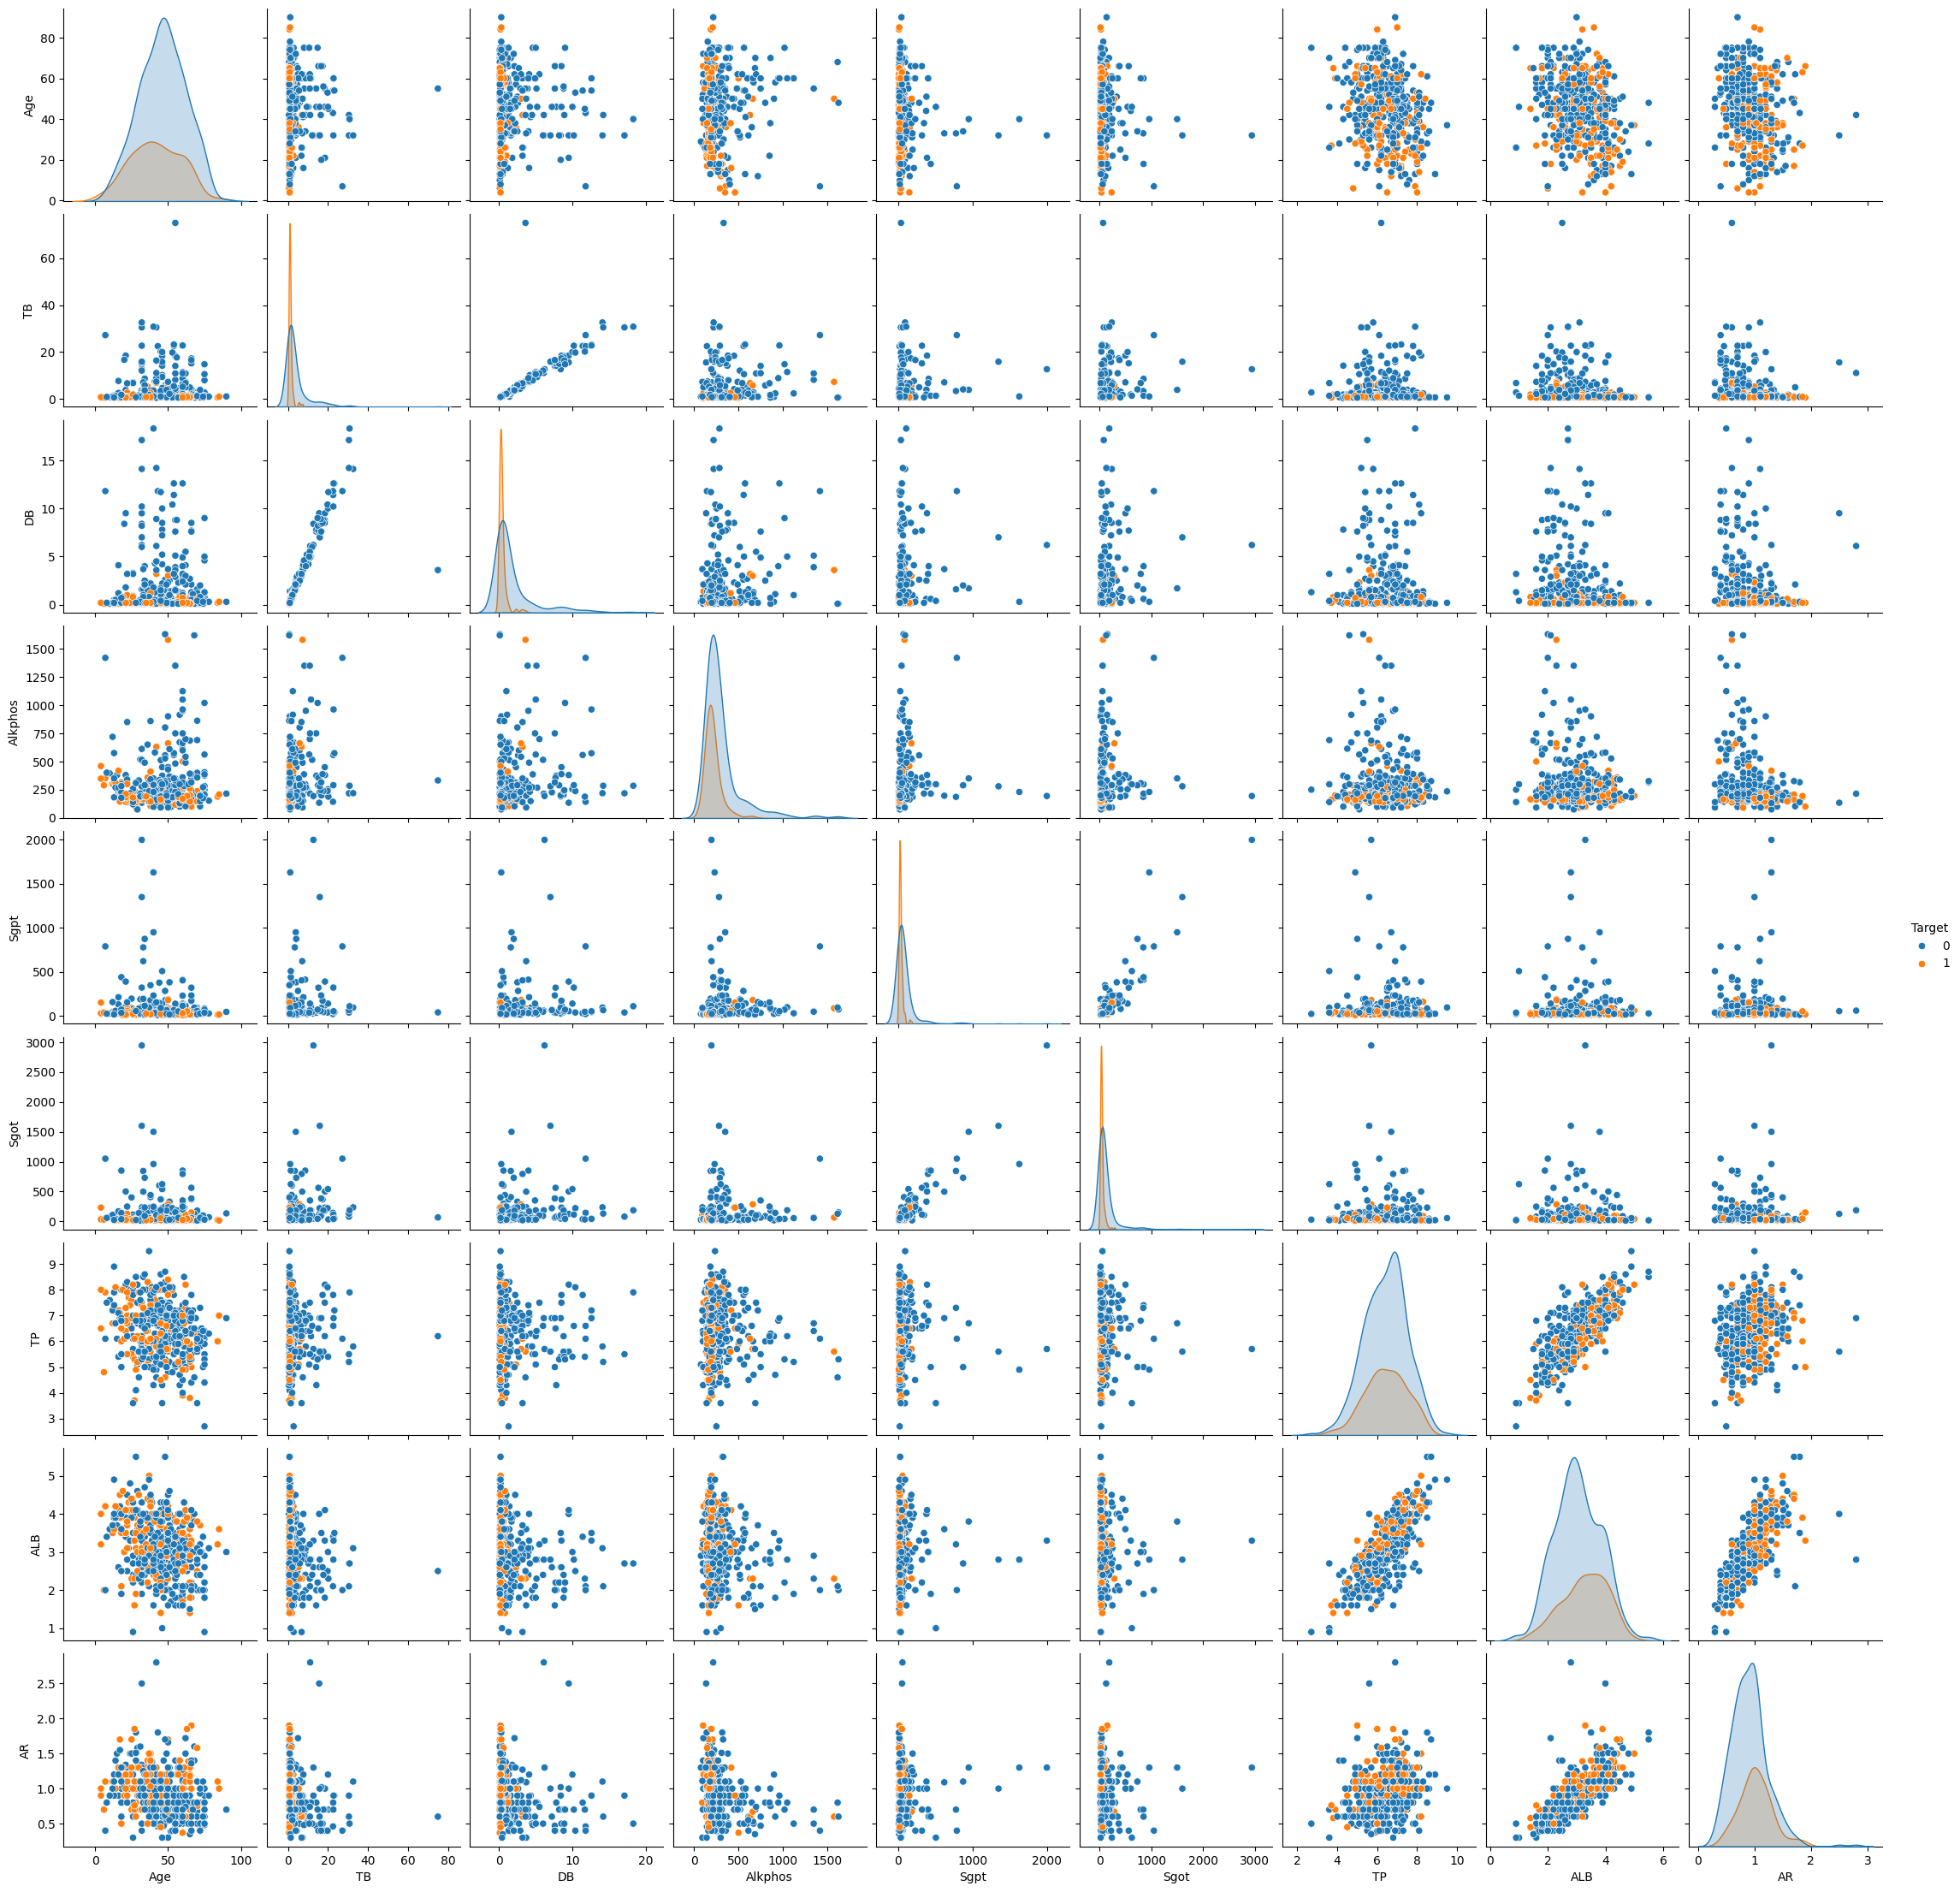

In [8]:
sns.pairplot(raw_data, hue = "Target")

In [9]:
raw_numdata = raw_data.drop(columns = ["Female", "Target"])
corr = raw_numdata.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = raw_numdata @ U

print(eigs)
print(X_pca.shape)

[2.82463156 2.10174352 1.43118055 0.84093437 0.88460761 0.63952997
 0.044745   0.0830351  0.14959234]
(463, 9)


<Figure size 600x400 with 0 Axes>

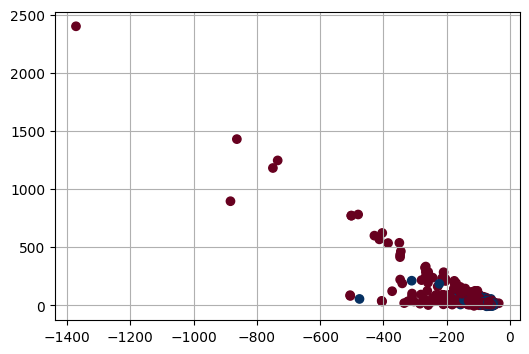

In [10]:
x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = raw_data['Target'], cmap = "RdBu")
_ = plt.grid()

In [11]:
sick_numdata = raw_data.drop(columns = ["Female", "Target"])[raw_data['Target'] == 0]
corr = sick_numdata.corr()

eigs, U = np.linalg.eig(corr) 
sick_pca = sick_numdata @ U

print(eigs)
print(sick_pca.shape)

[2.72097017 2.14208179 1.47309362 0.90460943 0.79655931 0.66467459
 0.15957238 0.05497367 0.08346502]
(331, 9)


<Figure size 600x400 with 0 Axes>

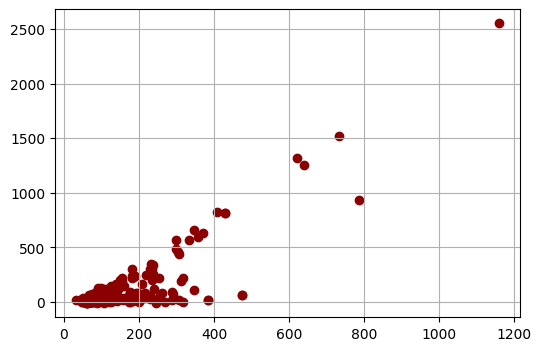

In [12]:
x = sick_pca.loc[:, 0]
y = sick_pca.loc[:, 1]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkred")
_ = plt.grid()

In [13]:
healthy_numdata = raw_data.drop(columns = ["Female", "Target"])[raw_data['Target'] == 1]
corr = healthy_numdata.corr()

eigs, U = np.linalg.eig(corr) 
healthy_pca = healthy_numdata @ U

print(eigs)
print(healthy_pca.shape)

[3.31745296 2.18729537 1.13108032 1.00219726 0.65735369 0.41528247
 0.26302742 0.01553821 0.0107723 ]
(132, 9)


<Figure size 600x400 with 0 Axes>

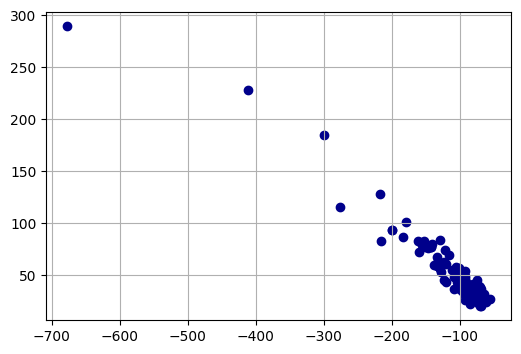

In [14]:
x = healthy_pca.loc[:, 0]
y = healthy_pca.loc[:, 1]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkblue")
_ = plt.grid()

# 2. Identifying anomalies

First of all, we have found clear anormal individuals (healthy and sick) which we should eliminate. Not eliminating them can be problematic when fitting the models or if we want to do resampling.

We remove 5 outliers from our sick patients:

In [15]:
sick_data = raw_data[raw_data['Target'] == 0]
healthy_data = raw_data[raw_data['Target'] == 1]

sick_data = sick_data[sick_pca.loc[:, 0] <= 600]
healthy_data = healthy_data[healthy_pca.loc[:, 1] <= 150]

data_v1 = pd.concat([sick_data, healthy_data], axis = 0)
data_v1.shape
data_v1.describe()

(455, 11)

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR
count,455.000,455.000,455.000,455.000,455.000,455.000,455.000,455.000,455.000
mean,45.110,3.172,1.397,273.413,61.484,80.343,6.432,3.115,0.943
std,16.212,6.013,2.628,195.895,95.195,120.652,1.056,0.795,0.318
min,4.000,0.400,0.100,75.000,10.000,11.000,2.700,0.900,0.300
25%,33.000,0.800,0.200,175.500,22.500,25.000,5.700,2.550,0.700
50%,45.000,1.000,0.300,206.000,33.000,41.000,6.500,3.100,0.920
75%,58.000,2.600,1.200,290.000,58.000,79.500,7.100,3.750,1.100
max,90.000,75.000,18.300,1630.000,875.000,850.000,9.500,5.500,2.800


[2.82497774 2.00315451 1.41047271 0.92204875 0.83086335 0.65465019
 0.04464246 0.14661052 0.16257977]
(455, 9)


<Figure size 600x400 with 0 Axes>

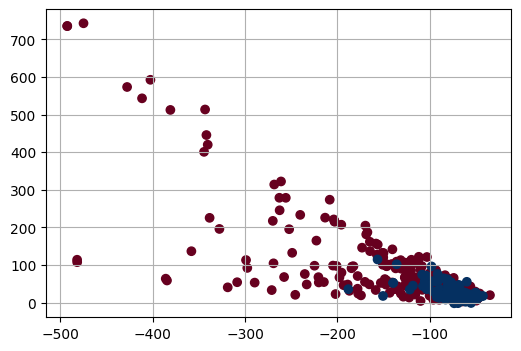

In [16]:
numdata_v1 = data_v1.drop(columns = ["Female", "Target"])
corr = numdata_v1.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = numdata_v1 @ U

print(eigs)
print(X_pca.shape)

x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = data_v1['Target'], cmap = "RdBu")
_ = plt.grid()

[2.73153164 2.01354903 1.47189865 0.93889552 0.78849148 0.6808072
 0.05506711 0.14912681 0.17063257]
(326, 9)


<Figure size 600x400 with 0 Axes>

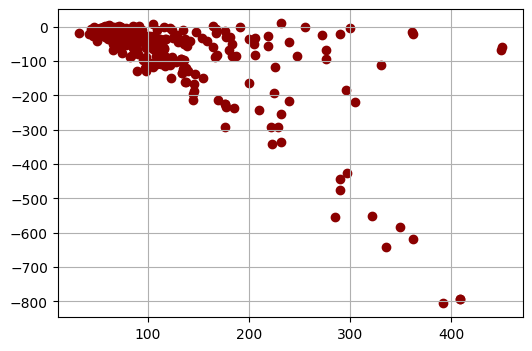

In [17]:
sicknumdata_v1 = numdata_v1[data_v1['Target'] == 0]
corr = sicknumdata_v1.corr()

eigs, U = np.linalg.eig(corr) 
sick_pca = sicknumdata_v1 @ U

print(eigs)
print(sick_pca.shape)

x = sick_pca.loc[:, 0]
y = sick_pca.loc[:, 1]
z = sick_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkred")
_ = plt.grid()

[2.66169106 2.16538989 1.21004531 1.18370869 0.81044446 0.451213
 0.48495229 0.01562661 0.01692869]
(129, 9)


<Figure size 600x400 with 0 Axes>

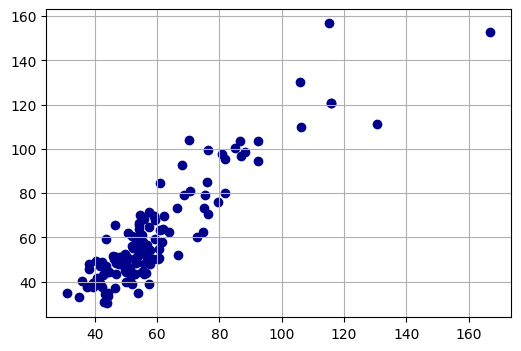

In [18]:
healthynumdata_v1 = numdata_v1[data_v1['Target'] == 1]
corr = healthynumdata_v1.corr()

eigs, U = np.linalg.eig(corr) 
healthy_pca = healthynumdata_v1 @ U

print(eigs)
print(healthy_pca.shape)

x = healthy_pca.loc[:, 0]
y = healthy_pca.loc[:, 1]
z = healthy_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = "darkblue")
_ = plt.grid()

Now we will take a look at variables separately, with the use of histograms and boxplots.

In [19]:
def histbox (data, column: str, n_bins: int = 10) -> None:
    fig, axes = plt.subplots(1, 2, gridspec_kw = {'width_ratios': [1, 4]}, figsize=(9,4))
    sns.boxplot(data = data, x = 'Target', y = column, hue = 'Target', ax = axes[0])
    
    sick = data[data["Target"] == 0]
    healthy = data[data["Target"] == 1]
    mean_sick = np.mean(sick[column])
    mean_healthy = np.mean(healthy[column])
    std_sick = np.std(sick[column])
    std_healthy = np.std(healthy[column])
    prop_sick = len(sick) / len(data)
    prop_healthy = len(healthy) / len(data)
    
    x = np.linspace(np.min(sick[column]), np.max(sick[column]), num = 500)
    y = np.linspace(np.min(healthy[column]), np.max(healthy[column]), num = 500)
    ax = sns.histplot(data = data, x = column, hue = 'Target', ax = axes[1],
                      bins = n_bins, stat = "density")
    ax.plot(x, norm.pdf(x, loc = mean_sick, scale = std_sick) * prop_sick)
    ax.plot(y, norm.pdf(y, loc = mean_healthy, scale = std_healthy) * prop_healthy)

In [20]:
data_v1.columns

Index(['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB',
       'AR', 'Target'],
      dtype='object')

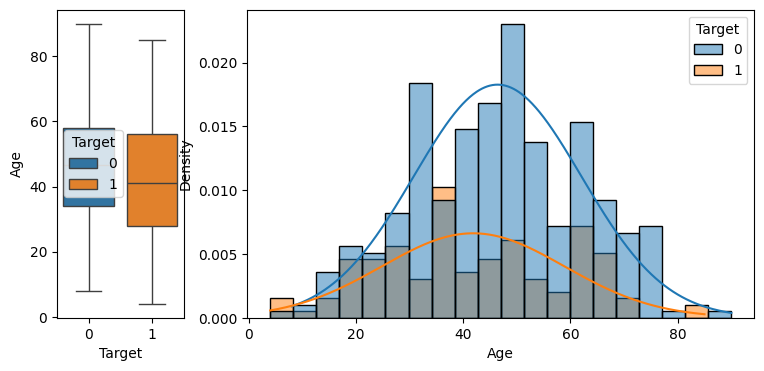

In [21]:
histbox(data_v1, "Age", 20)

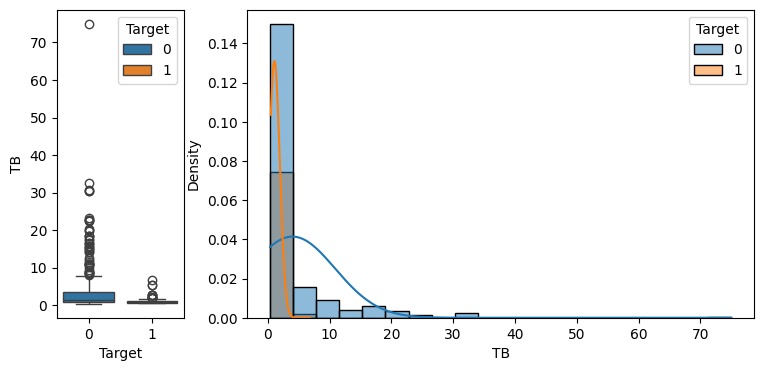

In [22]:
histbox(data_v1, "TB", 20)

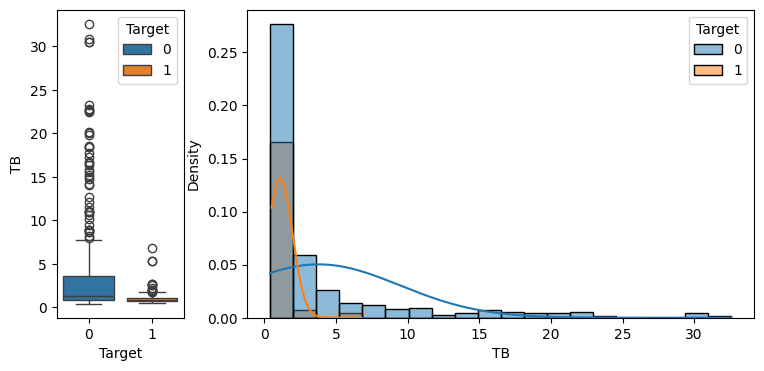

In [23]:
histbox(data_v1[data_v1["TB"] < 40], "TB", 20)

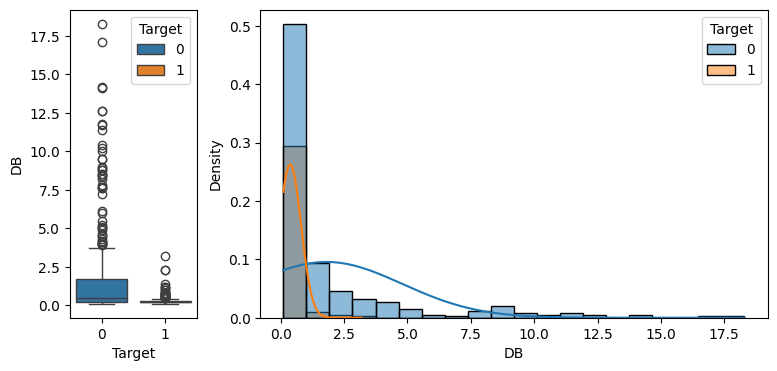

In [24]:
histbox(data_v1, "DB", 20)

## Direct / Total Ratio

Another variable derived from DB and TB that shows the ratio between the direct bilirubin and the total bilirubin. This might help make better decisions in some cases.

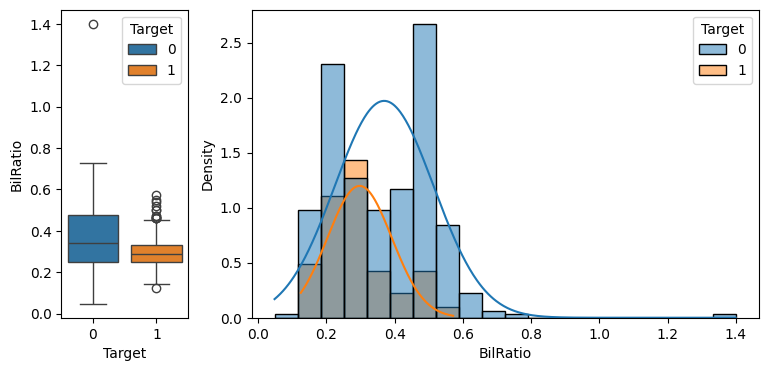

In [25]:
data_v1["BilRatio"] = data_v1["DB"] / data_v1["TB"]
histbox(data_v1, "BilRatio", 20)

# Alkphos

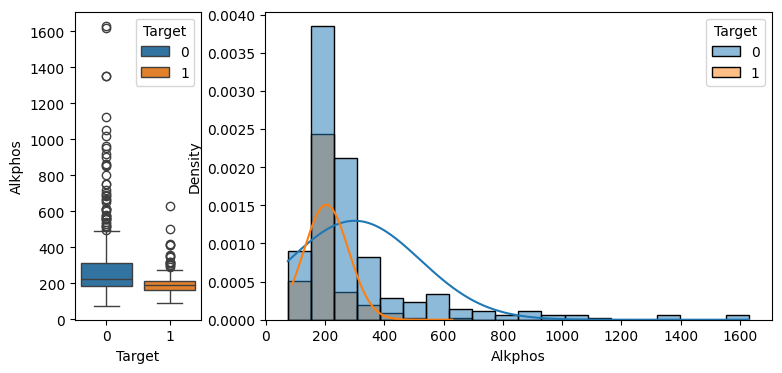

In [26]:
histbox(data_v1, "Alkphos", 20)

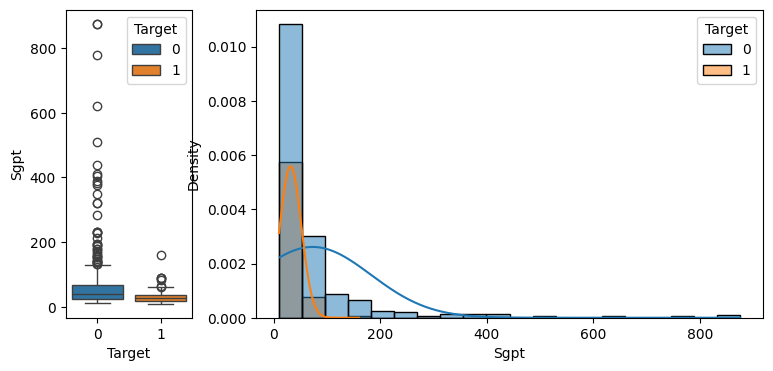

In [27]:
histbox(data_v1, "Sgpt", 20)

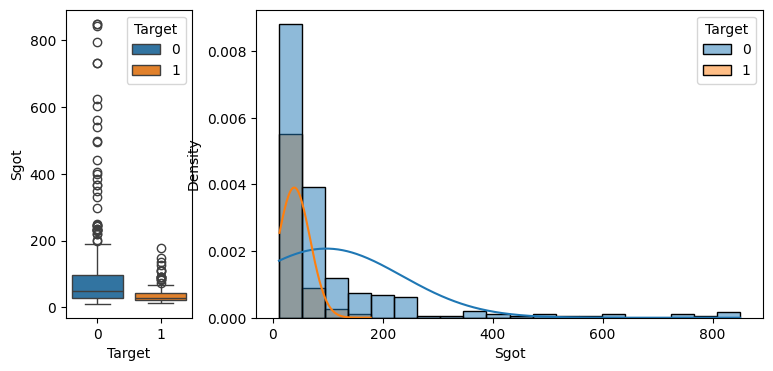

In [28]:
histbox(data_v1, "Sgot", 20)

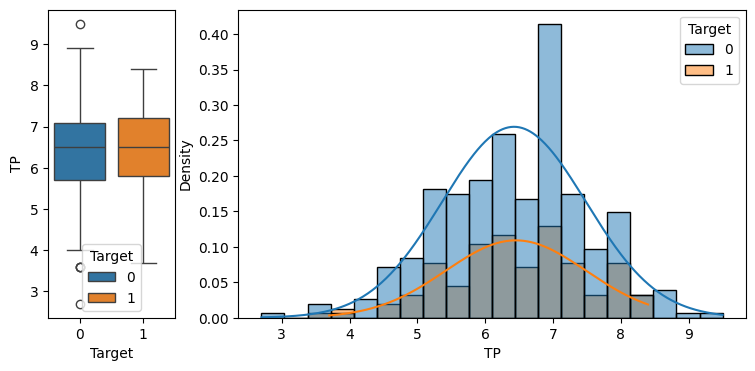

In [29]:
histbox(data_v1, "TP", 20)

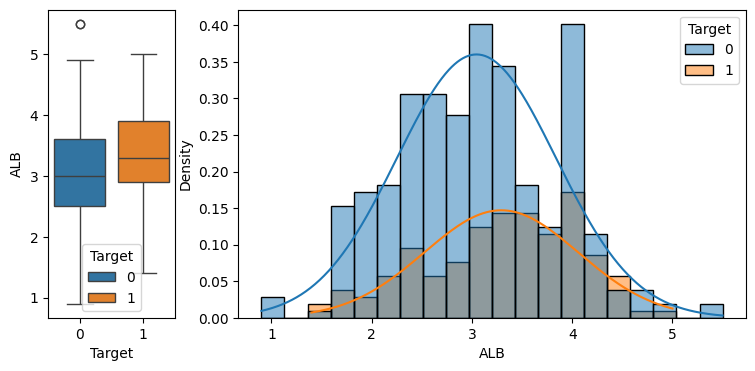

In [30]:
histbox(data_v1, "ALB", 20)

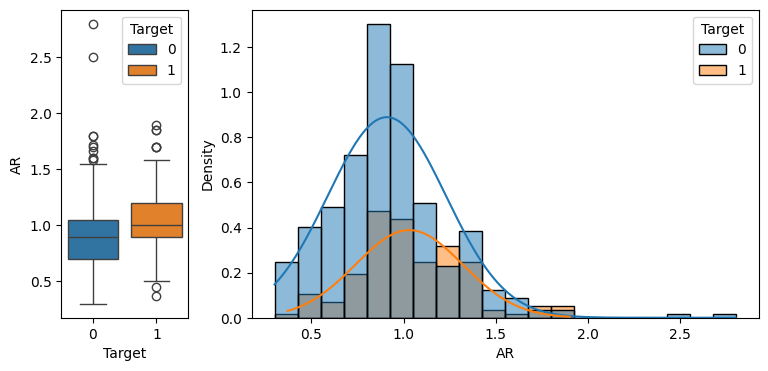

In [31]:
histbox(data_v1, "AR", 20)

In [32]:
(data_v1["AR"] < 2).value_counts()
data_v1 = data_v1[data_v1["AR"] < 2]

AR
True     453
False      2
Name: count, dtype: int64

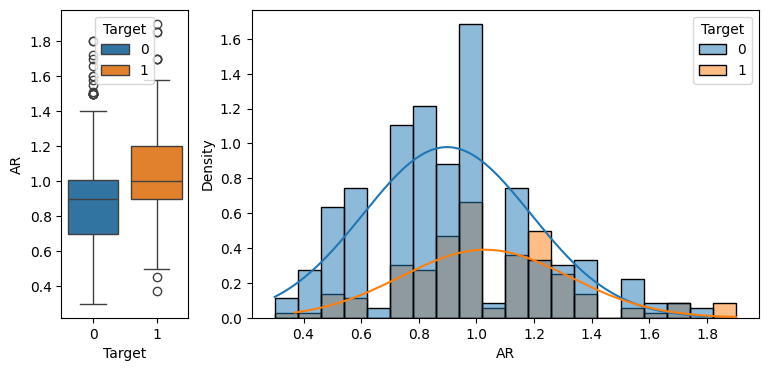

In [33]:
histbox(data_v1, "AR", 20)

In [34]:
(data_v1["Target"] == 1).value_counts()

Target
False    324
True     129
Name: count, dtype: int64

# Applying log transformations

In [35]:
data_v2 = data_v1.copy()

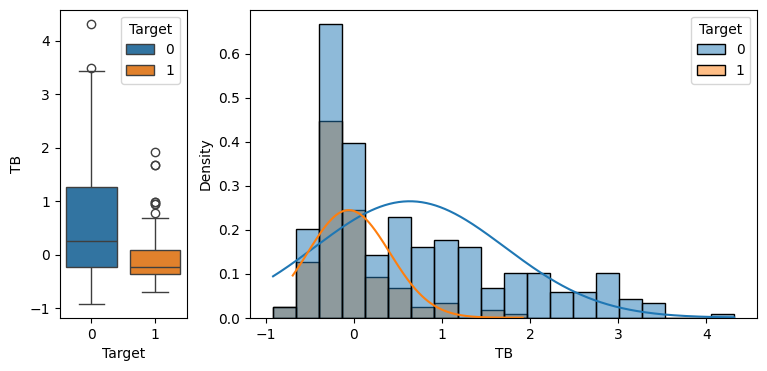

In [36]:
data_v2["TB"] = np.log(data_v1["TB"])
histbox(data_v2, "TB", 20)

In [37]:
(data_v2["TB"] > 4).value_counts()

TB
False    452
True       1
Name: count, dtype: int64

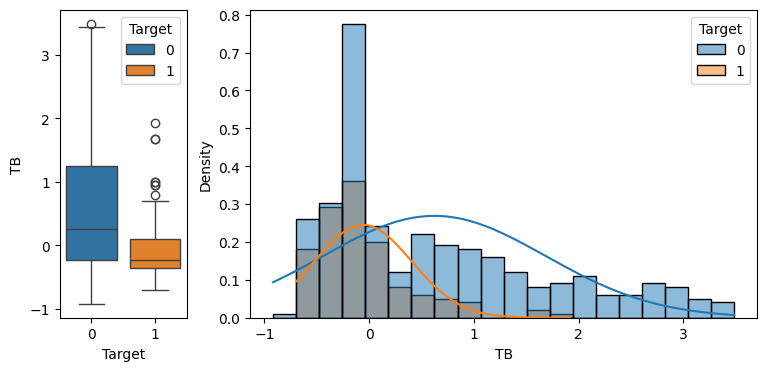

In [38]:
data_v2 = data_v2[data_v2["TB"] < 4]
histbox(data_v2, "TB", 20)

In [39]:
(np.logical_and(data_v2["Target"] == 1, data_v2["TB"] > 1.5)).value_counts()

False    449
True       3
Name: count, dtype: int64

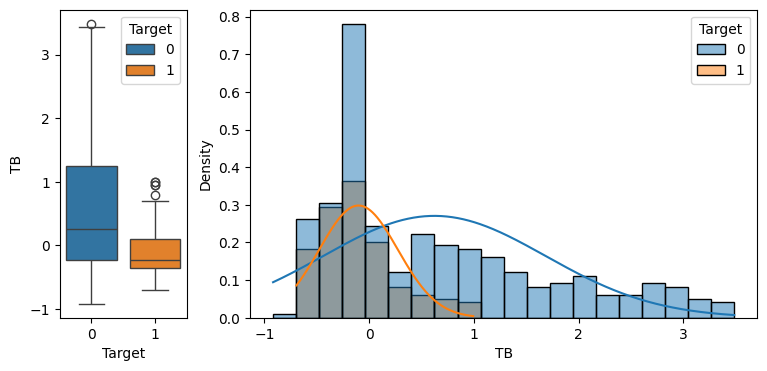

In [40]:
data_v2 = data_v2[np.logical_or(data_v2["Target"] == 0, data_v2["TB"] < 1.5)]
histbox(data_v2, "TB", 20)

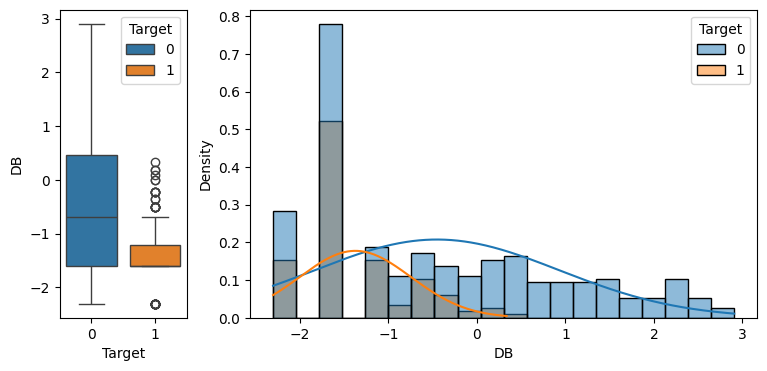

In [41]:
data_v2["DB"] = np.log(data_v1["DB"])
histbox(data_v2, "DB", 20)

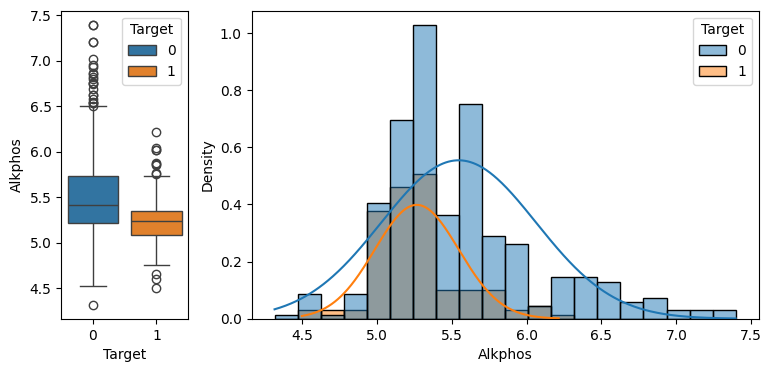

In [42]:
data_v2["Alkphos"] = np.log(data_v1["Alkphos"])
histbox(data_v2, "Alkphos", 20)

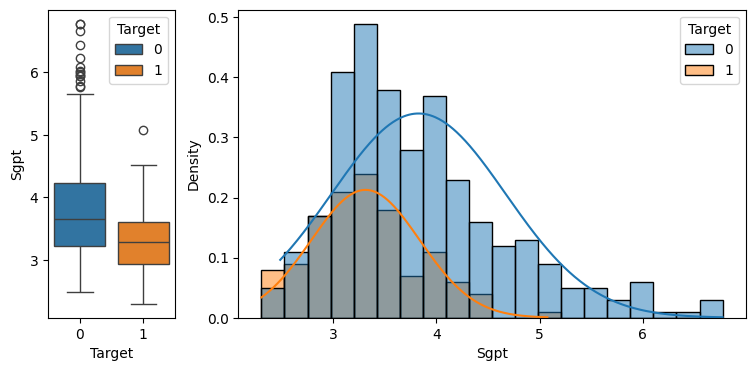

In [43]:
data_v2["Sgpt"] = np.log(data_v1["Sgpt"])
histbox(data_v2, "Sgpt", 20)

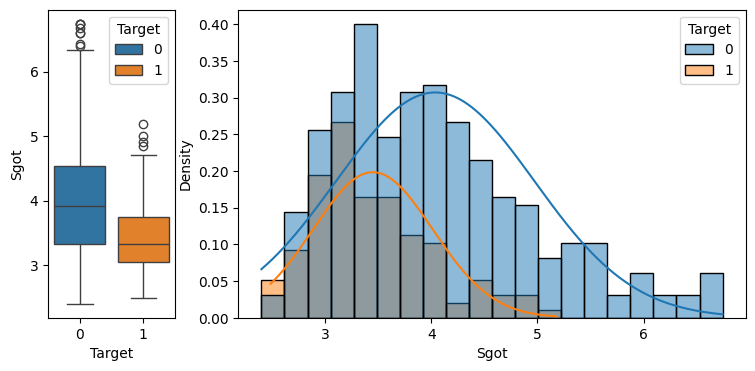

In [44]:
data_v2["Sgot"] = np.log(data_v1["Sgot"])
histbox(data_v2, "Sgot", 20)

# Resampling

In [45]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC, SVMSMOTE, ADASYN

In [46]:
data_v3 = data_v2.copy()

In [47]:
data_v3.isna().value_counts()

Age    Female  TB     DB     Alkphos  Sgpt   Sgot   TP     ALB    AR     Target  BilRatio
False  False   False  False  False    False  False  False  False  False  False   False       449
Name: count, dtype: int64

In [48]:
numdata_v3 = data_v3.drop(columns = ["Female", "Target"])
numdata_v3.columns

Index(['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR',
       'BilRatio'],
      dtype='object')

In [49]:
stdscaler = StandardScaler()
scaled_data = pd.DataFrame(stdscaler.fit_transform(numdata_v3),
                           columns = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR', 'BilRatio'])
scaled_data.index = data_v3.index
scaled_data["Female"] = data_v3["Female"]
scaled_data.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,BilRatio
count,4.490e+02,4.490e+02,4.490e+02,4.490e+02,4.490e+02,4.490e+02,4.490e+02,4.490e+02,4.490e+02,4.490e+02
mean,-2.769e-17,-1.583e-17,-4.748e-17,4.748e-16,-6.330e-17,-4.589e-16,-5.113e-16,-1.583e-17,-1.187e-16,-1.108e-16
std,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00,1.001e+00
min,-2.530e+00,-1.368e+00,-1.236e+00,-2.397e+00,-1.718e+00,-1.659e+00,-3.539e+00,-2.787e+00,-2.138e+00,-1.644e+00
25%,-7.481e-01,-6.585e-01,-6.980e-01,-6.201e-01,-7.359e-01,-7.346e-01,-7.004e-01,-6.521e-01,-7.949e-01,-7.221e-01
50%,5.092e-02,-4.301e-01,-3.833e-01,-2.922e-01,-2.308e-01,-2.053e-01,5.670e-02,-2.433e-02,-1.234e-01,-3.534e-01
75%,7.885e-01,4.660e-01,6.924e-01,4.203e-01,4.719e-01,5.468e-01,6.245e-01,8.546e-01,5.482e-01,8.377e-01
max,2.755e+00,3.136e+00,2.807e+00,4.017e+00,3.853e+00,3.237e+00,2.896e+00,2.989e+00,3.234e+00,7.757e+00


In [50]:
scaled_data.isna().value_counts()

Age    TB     DB     Alkphos  Sgpt   Sgot   TP     ALB    AR     BilRatio  Female
False  False  False  False    False  False  False  False  False  False     False     449
Name: count, dtype: int64

In [51]:
smotenc = SMOTENC(sampling_strategy = "minority", random_state = 42,
                  categorical_features = ["Female"])
X_resampled, y_resampled = smotenc.fit_resample(scaled_data, data_v3['Target'])
resampled_data = X_resampled
resampled_data['Target'] = y_resampled
resampled_data.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,BilRatio
count,646.000,646.000,646.000,646.000,646.000,646.000,646.000,646.000,646.000,646.000
mean,-0.085,-0.165,-0.159,-0.135,-0.150,-0.156,0.037,0.098,0.106,-0.123
std,0.994,0.891,0.904,0.899,0.912,0.917,0.981,0.981,0.974,0.927
min,-2.530,-1.368,-1.236,-2.397,-1.718,-1.659,-3.539,-2.787,-2.138,-1.644
25%,-0.810,-0.755,-0.698,-0.680,-0.784,-0.829,-0.606,-0.634,-0.459,-0.722
50%,-0.036,-0.538,-0.562,-0.375,-0.348,-0.398,0.151,0.101,0.180,-0.459
75%,0.689,0.131,0.356,0.263,0.287,0.270,0.719,0.855,0.587,0.712
max,2.755,3.136,2.807,4.017,3.853,3.237,2.896,2.989,3.234,7.757


In [52]:
resampled_data.isna().value_counts()

Age    TB     DB     Alkphos  Sgpt   Sgot   TP     ALB    AR     BilRatio  Female  Target
False  False  False  False    False  False  False  False  False  False     False   False     646
Name: count, dtype: int64

[3.92110577 2.13430882 1.22267675 0.87733974 0.8339025  0.52857697
 0.02008889 0.00398871 0.19327757 0.26473427]
(646, 10)


<Figure size 600x400 with 0 Axes>

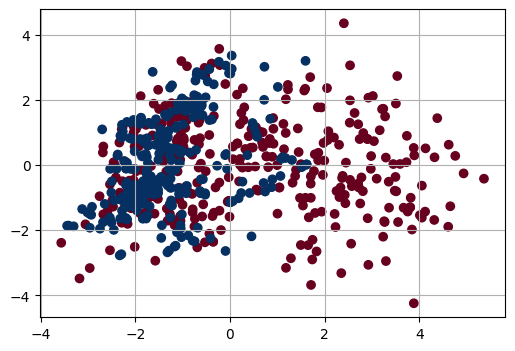

In [53]:
numdata = resampled_data.drop(columns = ["Female", "Target"])
corr = numdata.corr()

eigs, U = np.linalg.eig(corr) 
X_pca = numdata @ U

print(eigs)
print(X_pca.shape)

x = X_pca.loc[:, 0]
y = X_pca.loc[:, 1]
z = X_pca.loc[:, 2]

plt.figure(figsize = (6, 4))
_ = plt.scatter(x = x, y = y, c = resampled_data['Target'], cmap = "RdBu")
_ = plt.grid()

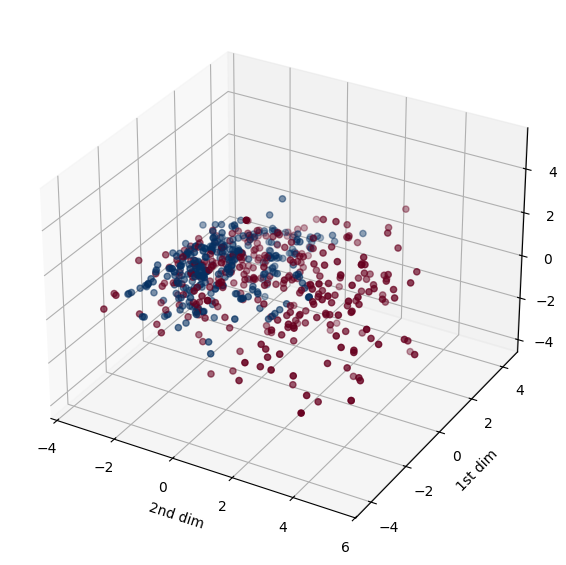

In [54]:
fig = plt.figure(figsize = (7, 8))
ax = fig.add_subplot(projection = '3d')
ax.scatter(xs = x, ys = y, zs = z, c = resampled_data['Target'], cmap = "RdBu")

_ = ax.set_xlabel("2nd dim")
_ = ax.set_ylabel("1st dim")
_ = ax.set_zlabel("3rd dim")

In [55]:
resampled_data.to_csv('resampled_train.csv', index = False, header = False)
resampled_data.columns

Index(['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR',
       'BilRatio', 'Female', 'Target'],
      dtype='object')

# Test processing

In [56]:
test_data = read_csv("test_data_ILDS.csv", delimiter=',', header=None)
test_data.columns = ['Age', 'Female', 'TB', 'DB', 'Alkphos', 'Sgpt', 
                    'Sgot', 'TP', 'ALB', 'AR']
test_data['Female'] = test_data['Female'].astype('category')

test_data["BilRatio"] = test_data["DB"] / test_data["TB"]

In [57]:
test_data_v2 = test_data.copy()

In [58]:
test_data_v2["TB"] = np.log(test_data["TB"])
test_data_v2["DB"] = np.log(test_data["DB"])
test_data_v2["Alkphos"] = np.log(test_data["Alkphos"])
test_data_v2["Sgpt"] = np.log(test_data["Sgpt"])
test_data_v2["Sgot"] = np.log(test_data["Sgot"])

test_data_v2.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,BilRatio
count,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000
mean,44.388,0.464,-0.603,5.561,3.878,4.101,6.720,3.253,0.964,0.435
std,15.933,1.024,1.372,0.640,0.990,1.152,1.182,0.793,0.325,0.603
min,11.000,-0.511,-2.303,4.143,2.398,2.303,2.800,1.400,0.300,0.111
25%,32.750,-0.223,-1.609,5.163,3.209,3.359,6.000,2.800,0.800,0.250
50%,42.000,0.000,-1.204,5.366,3.651,3.784,6.900,3.200,1.000,0.333
75%,58.000,0.833,0.262,5.895,4.304,4.653,7.500,3.900,1.100,0.475
max,75.000,3.757,2.981,7.654,7.427,8.503,9.600,4.900,2.500,5.000


In [59]:
num_test = test_data_v2.drop(columns = ["Female"])
scaled_test = pd.DataFrame(stdscaler.transform(num_test),
                           columns = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR', 'BilRatio'])
scaled_test["Female"] = test_data_v2["Female"]
scaled_test.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,BilRatio
count,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000,116.000
mean,-0.048,0.044,0.083,0.192,0.245,0.259,0.265,0.167,0.090,0.640
std,0.979,1.048,1.064,1.333,1.234,1.297,1.119,0.996,1.092,4.443
min,-2.100,-0.953,-1.236,-2.760,-1.600,-1.767,-3.445,-2.159,-2.138,-1.746
25%,-0.763,-0.658,-0.698,-0.635,-0.589,-0.577,-0.416,-0.401,-0.459,-0.722
50%,-0.195,-0.430,-0.383,-0.213,-0.039,-0.098,0.435,0.101,0.212,-0.108
75%,0.788,0.422,0.755,0.890,0.775,0.881,1.003,0.980,0.548,0.939
max,1.833,3.415,2.864,4.555,4.666,5.216,2.990,2.236,5.249,34.302


In [60]:
scaled_test.to_csv('scaled_test.csv', index = False, header = False)

## Experimental: reducing dimension

We may benefit from reducing dimension. We have a lot of dimensions in PCA which hold very small amounts of variability, but they might still be relevant. We can try to reduce dimensionality by removing variables or non-important principal components. This should make our models more stable.

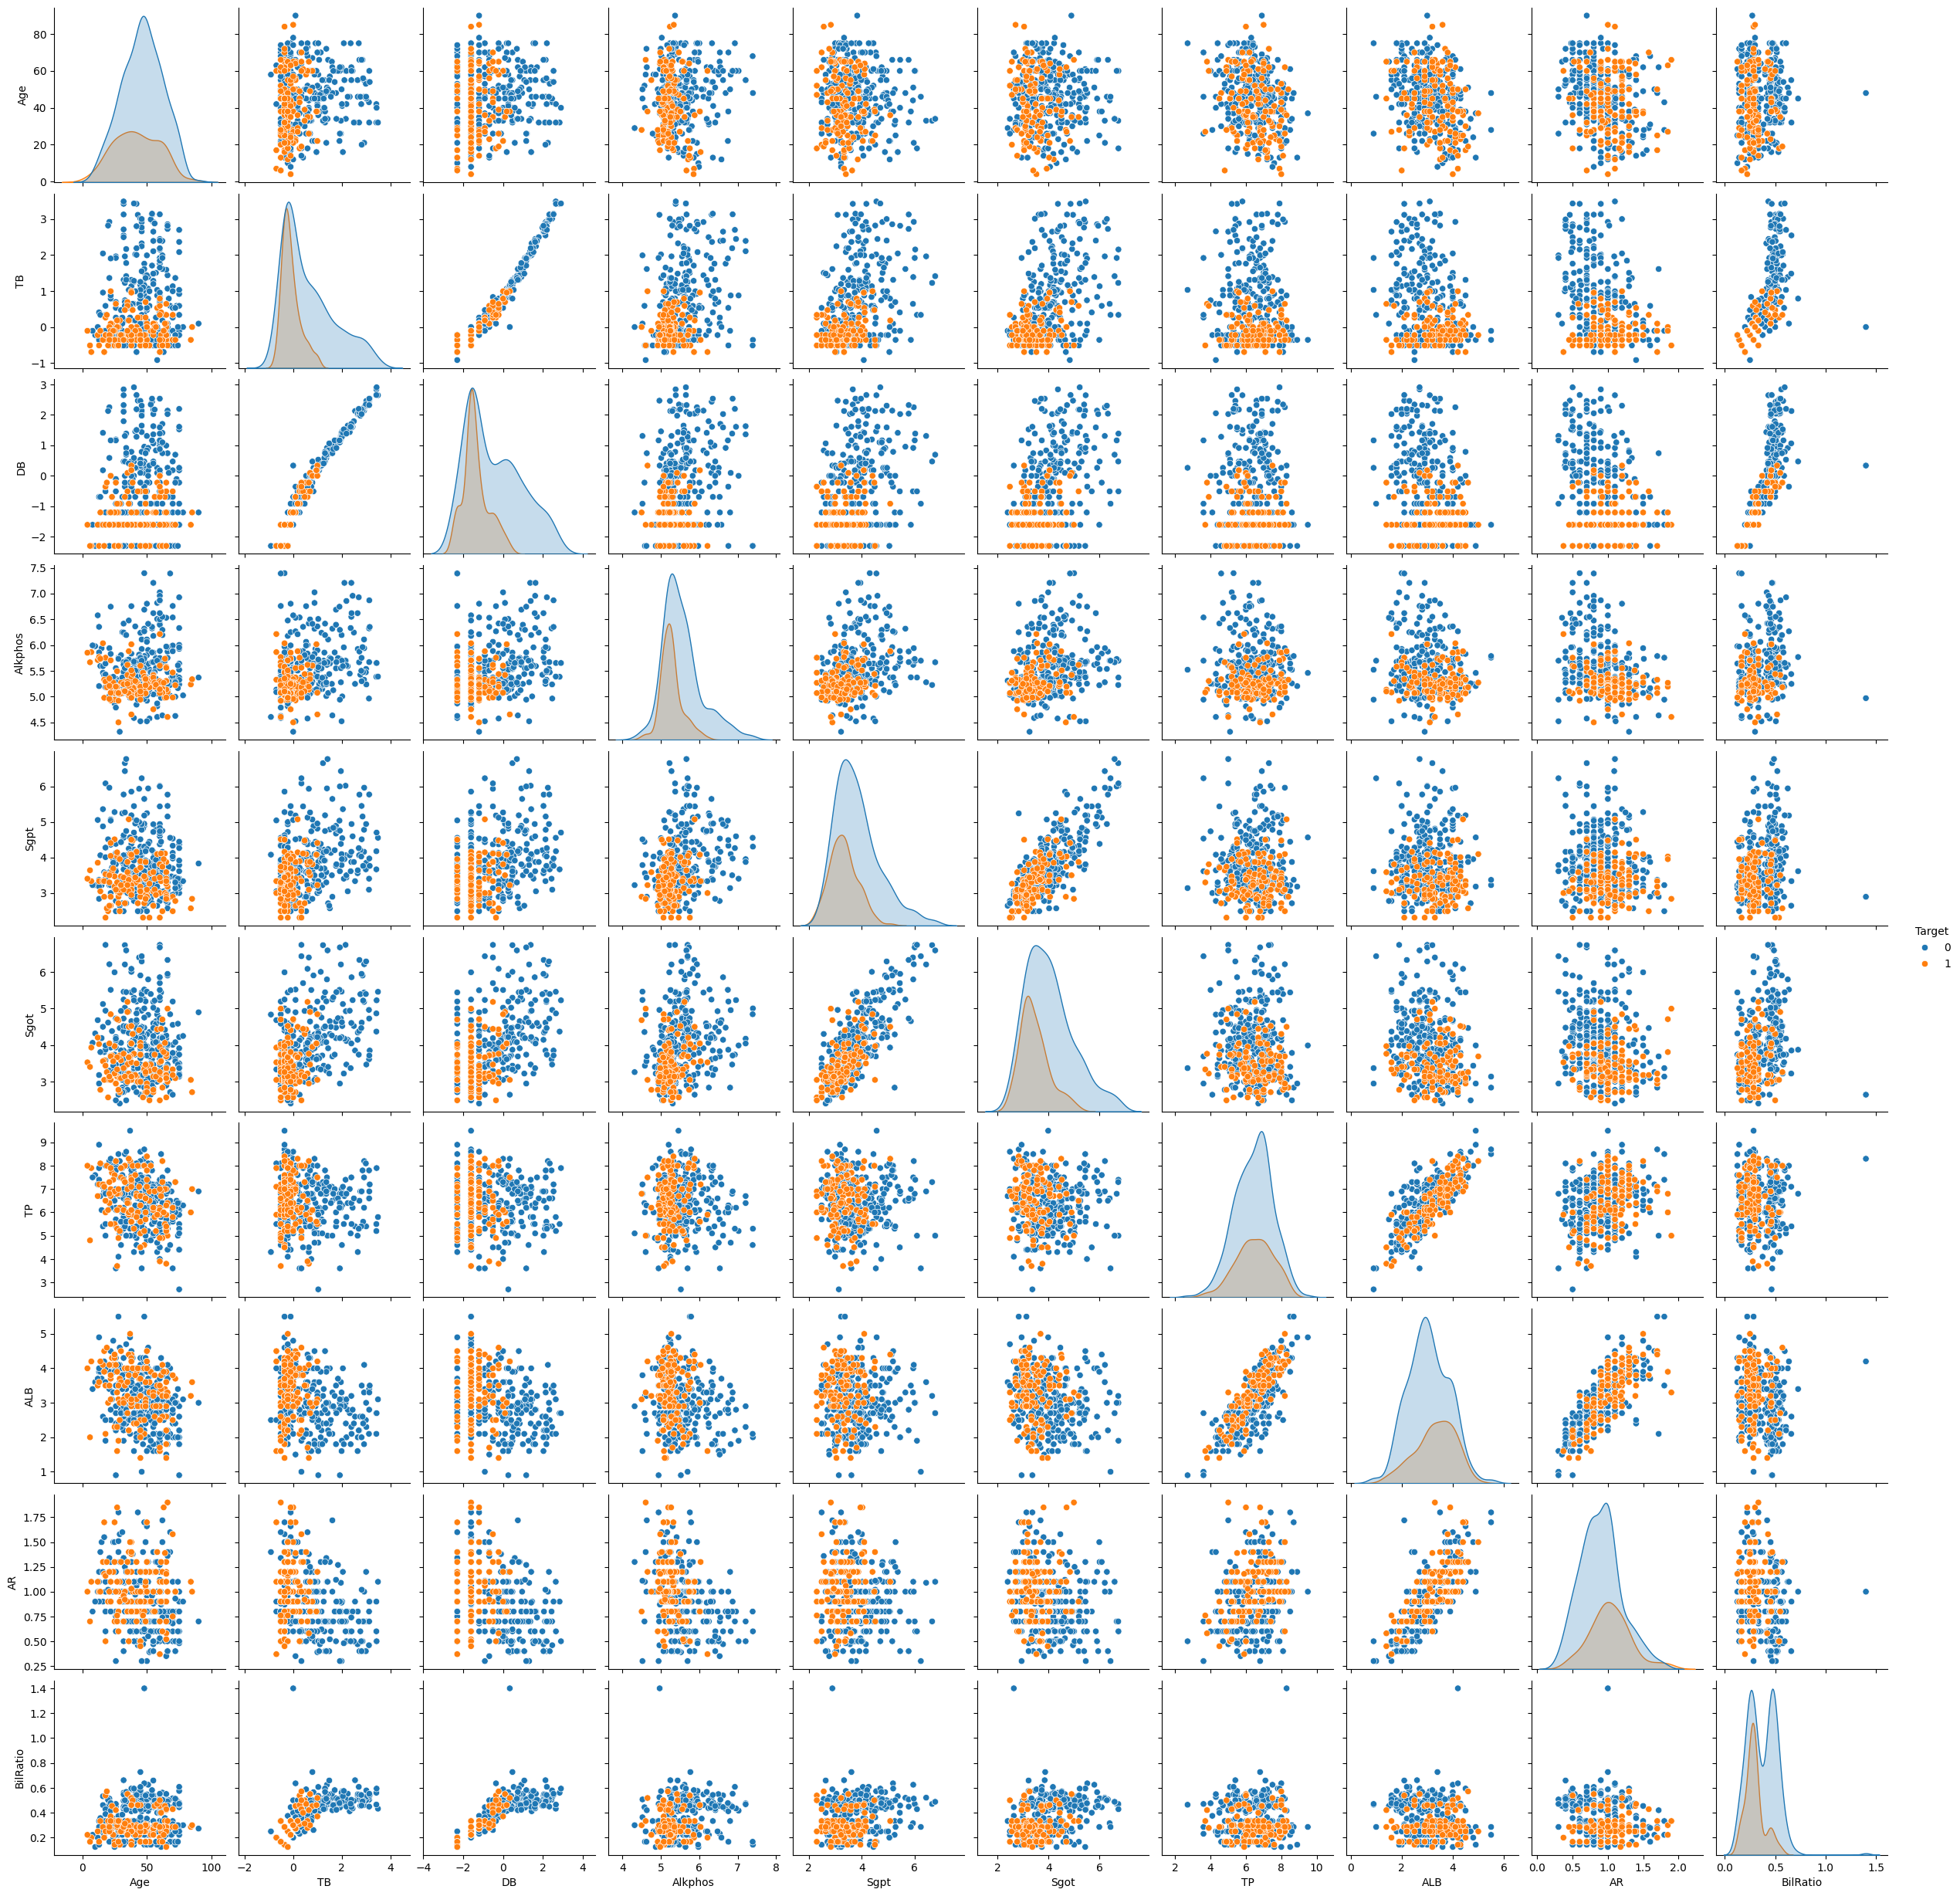

In [61]:
sns.pairplot(data_v3, hue = "Target")

<Axes: >

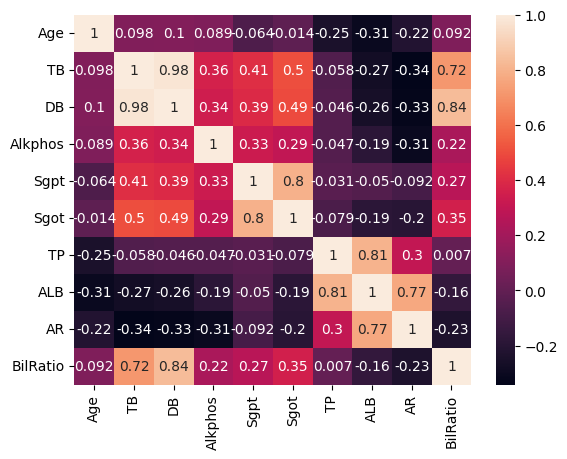

In [62]:
from sklearn.feature_selection import r_regression

scaled_data_num = scaled_data.drop(columns = ["Female"])
p = scaled_data_num.shape[1]
names = scaled_data_num.columns

pearson = np.ndarray(shape = (p, p))
for i, col in enumerate(names):
    pearson[i, :] = r_regression(scaled_data_num, scaled_data_num[col])
pearson = pd.DataFrame(pearson, columns = names, index = names)

sns.heatmap(pearson, annot = True)

We can also obtain an approximated information matrix to gauge how much information about the target variable we obtain from the principal components. We

<Axes: >

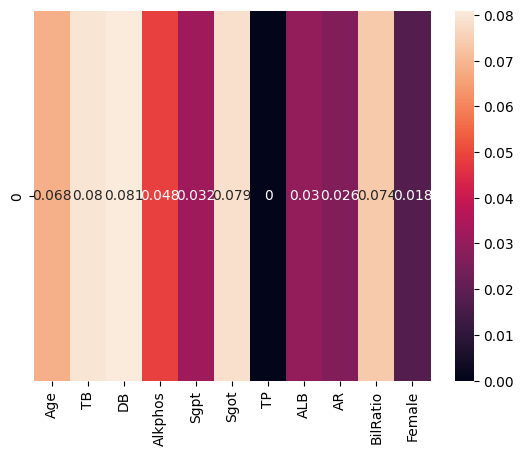

In [130]:
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression

# def calc_MI(x, target, bins):
#     minv = np.min(x)
#     maxv = np.max(x)
#     binsize = (maxv - minv) / bins
#     x_ = np.array(x.copy())
#     for i in range(x_.shape[0]):
#         for j in range(bins):
#             if minv + j * binsize <= x_[i] <= minv + (j + 1) * binsize:
#                 x_[i] = j
#                 break
#     return mutual_info_score(x_, target)

# Imatt = np.ndarray(shape = (11))
# bins = 10
# for i in range(10):
#     Imatt[i] = calc_MI(scaled_data_num.iloc[:, i], data_v3.Target, bins)
# Imatt[10] = mutual_info_score(scaled_data.Female, data_v3.Target)
# Imatt = Imatt.reshape((1, -1))

mi = mutual_info_regression(scaled_data, data_v3.Target, n_neighbors = 5, random_state = 42)
columns = ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB',
       'AR', 'BilRatio', 'Female']
Imatt = pd.DataFrame(data = mi.reshape((1, 11)), columns = columns)
sns.heatmap(Imatt, annot=True)

What we propose is to remove the Total Protein, Direct Bilirubin and SGPT variables due to their high correlation with other variables.

[2.79612879 1.43396239 0.8811811  0.79117999 0.63512964 0.21434062
 0.24807748]
(449, 7)


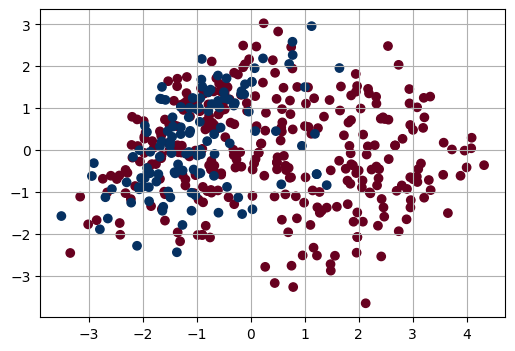

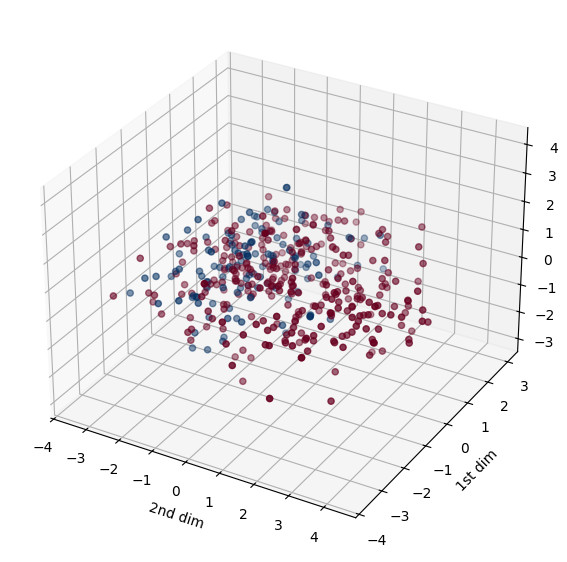

In [85]:
def plot_PCA (X: np.ndarray, target: np.ndarray,
              axes: tuple[int, int, int] = (0, 1, 2), plot_3D: bool = True) -> np.ndarray:
    corr = X.corr()

    eigs, U = np.linalg.eig(corr) 
    X_pca = X @ U

    print(eigs)
    print(X_pca.shape)

    x = X_pca.loc[:, axes[0]]
    y = X_pca.loc[:, axes[1]]
    z = X_pca.loc[:, axes[2]]

    plt.figure(figsize = (6, 4))
    _ = plt.scatter(x = x, y = y, c = target, cmap = "RdBu")
    _ = plt.grid()
    
    if plot_3D:
        fig = plt.figure(figsize = (7, 8))
        ax = fig.add_subplot(projection = '3d')
        ax.scatter(xs = x, ys = y, zs = z, c = target, cmap = "RdBu")

        _ = ax.set_xlabel("2nd dim")
        _ = ax.set_ylabel("1st dim")
        _ = ax.set_zlabel("3rd dim")
    return U

data_fs = scaled_data.copy().drop(columns = ["DB", "TP", "Sgpt"])

_ = plot_PCA(data_fs.drop(columns = "Female"), data_v3.Target)

### Oversampling over the reduced dimension dataset

In [65]:
smotenc = SMOTENC(sampling_strategy = "minority", random_state = 42,
                  categorical_features = ["Female"])
X_resampled, y_resampled = smotenc.fit_resample(data_fs, data_v3['Target'])
resampled_data_fs = X_resampled
resampled_data_fs['Target'] = y_resampled
resampled_data_fs.describe()

,Age,TB,Alkphos,Sgot,ALB,AR,BilRatio
count,646.000,646.000,646.000,646.000,646.000,646.000,646.000
mean,-0.087,-0.161,-0.129,-0.150,0.093,0.103,-0.121
std,0.997,0.891,0.899,0.916,0.985,0.979,0.925
min,-2.530,-1.368,-2.397,-1.659,-2.787,-2.138,-1.644
25%,-0.810,-0.778,-0.680,-0.804,-0.573,-0.469,-0.722
50%,-0.011,-0.538,-0.375,-0.416,0.101,0.161,-0.459
75%,0.724,0.146,0.270,0.235,0.855,0.630,0.712
max,2.755,3.136,4.017,3.237,2.989,3.234,7.757


In [66]:
resampled_data_fs.to_csv('resampled_train_fs.csv', index = False, header = False)
resampled_data_fs.columns

Index(['Age', 'TB', 'Alkphos', 'Sgot', 'ALB', 'AR', 'BilRatio', 'Female',
       'Target'],
      dtype='object')

In [67]:
scaled_test_fs = scaled_test.drop(columns = ["DB", "TP", "Sgpt"])
scaled_test_fs.to_csv('scaled_test_fs.csv', index = False, header = False)
scaled_test_fs.columns

Index(['Age', 'TB', 'Alkphos', 'Sgot', 'ALB', 'AR', 'BilRatio', 'Female'], dtype='object')

### NOT oversampling over the reduced dimension dataset

In [87]:
data_fs["Target"] = data_v3.Target
data_fs.head()

,Age,TB,Alkphos,Sgot,ALB,AR,BilRatio,Female,Target
1,0.174,1.109,0.362,0.488,-0.903,-1.399,1.203,0,0
2,-0.379,0.227,-0.573,0.288,1.482,1.488,0.927,0,0
3,-1.363,-0.430,-0.232,0.575,-0.024,0.212,-0.353,0,0
4,-0.195,-0.795,-0.926,0.589,0.101,0.414,-0.459,1,0
8,0.543,2.761,1.784,-0.293,0.352,-0.459,1.154,1,0


In [69]:
data_fs.to_csv('scaled_train_fs.csv', index = False, header = False)

### Minimum preprocessing (only removing outliers and TP, DB and SGPT) 

In [70]:
data_minimal = data_v3.copy().drop(columns = ["TP", "DB", "Sgpt"])
# To preserve column order
data_minimal = data_minimal.drop(columns = ["Female", "Target"])
data_minimal["Female"] = data_v3.Female
data_minimal["Target"] = data_v3.Target
# Save
data_minimal.to_csv("minimal_train_fs.csv", index = False, header = False)
data_minimal.describe()

,Age,TB,Alkphos,Sgot,ALB,AR,BilRatio
count,449.000,449.000,449.000,449.000,449.000,449.000,449.000
mean,45.171,0.420,5.468,3.871,3.119,0.937,0.348
std,16.289,0.978,0.481,0.889,0.797,0.298,0.136
min,4.000,-0.916,4.317,2.398,0.900,0.300,0.125
25%,33.000,-0.223,5.170,3.219,2.600,0.700,0.250
50%,46.000,0.000,5.328,3.689,3.100,0.900,0.300
75%,58.000,0.875,5.670,4.357,3.800,1.100,0.462
max,90.000,3.484,7.396,6.745,5.500,1.900,1.400


In [71]:
test_minimal = test_data_v2.drop(columns = ["TP", "DB", "Sgpt"])
# To preserver order
test_minimal = test_minimal.drop(columns = "Female")
test_minimal["Female"] = test_data_v2.Female
# Saving
test_minimal.to_csv("minimal_test_fs.csv", index = False, header = False)
test_minimal.head()

,Age,TB,Alkphos,Sgot,ALB,AR,BilRatio,Female
0,11,-0.357,6.384,3.367,4.2,1.40,0.143,0
1,62,0.588,5.412,5.043,4.0,0.80,0.500,0
2,60,-0.357,5.159,2.639,4.2,1.10,0.286,0
3,60,1.740,5.366,6.745,3.2,0.78,0.491,0
4,48,-0.105,5.165,3.989,2.7,0.90,0.222,1


## Experimental: Using principal components

Some of the principal components might impose clearer separations between the sick and healthy patients. Indeed, we can see that practically only the first two principal components and the sixth component allow us to separate the data well enough (especially the first component), while the others might make slight improvements but are not very significant.

[2.79612879 1.43396239 0.8811811  0.79117999 0.63512964 0.21434062
 0.24807748]
(449, 7)


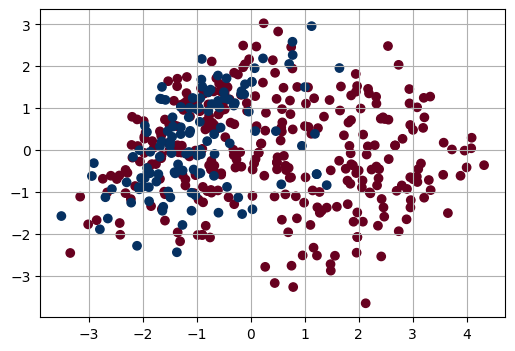

In [115]:
data_fs_num = data_fs.drop(columns = ["Female", "Target"])
U = plot_PCA(data_fs_num, data_fs.Target, axes = (0, 1, 2), plot_3D = False)

<Axes: >

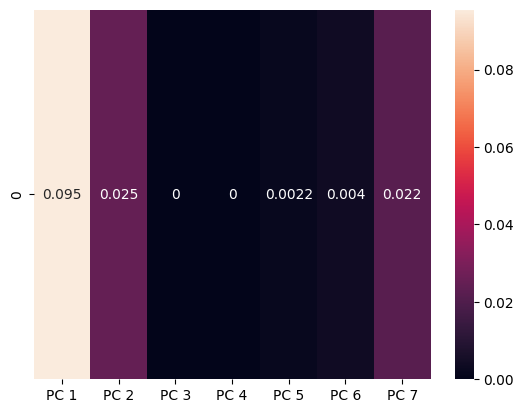

In [138]:
X_pca = data_fs_num @ U
mi = mutual_info_regression(X_pca, data_v3.Target, n_neighbors = 5, random_state = 67)
columns = [f'PC {i}' for i in range(1, 8)]
Imatt = pd.DataFrame(data = mi.reshape((1, 7)), columns = columns)
sns.heatmap(Imatt, annot=True)

In [148]:
data_minimal_num = data_minimal.drop(columns = ["Female", "Target"])
data_v3_pca = data_minimal_num @ U
data_v3_pca.columns = columns
data_v3_pca["Female"] = data_fs.Female
data_v3_pca["Target"] = data_fs.Target
data_v3_pca.head()

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,Female,Target
1,11.816,15.953,32.554,26.186,13.847,5.593,0.579,0,0
2,8.429,11.248,26.634,22.655,11.635,5.408,1.109,0,0
3,5.942,5.503,14.505,15.412,7.840,3.217,1.505,0,0
4,9.030,13.531,28.295,23.627,12.915,5.159,1.791,1,0
8,13.133,17.474,37.273,29.536,14.377,6.673,-0.699,1,0


In [149]:
data_v3_pca.to_csv("pca_train_fs.csv", index = False, header = False)

In [150]:
test_minimal_num = test_minimal.drop(columns = ["Female"])
test_pca = test_minimal_num @ U
test_pca["Female"] = scaled_test_fs.Female
test_pca.to_csv("pca_test_fs.csv", index = False, header = False)

## Experimental: Undersampling

In [73]:
from imblearn.under_sampling import NearMiss

undersampler = NearMiss(sampling_strategy = 0.5)
X_undersamp, y_undersamp = undersampler.fit_resample(scaled_data, data_v3.Target)
X_undersamp.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,BilRatio
count,378.000,378.000,378.000,378.000,378.000,378.000,378.000,378.000,378.000,378.000
mean,-0.047,-0.286,-0.270,-0.184,-0.185,-0.204,0.051,0.123,0.133,-0.192
std,1.011,0.660,0.737,0.771,0.801,0.794,0.966,0.961,0.957,0.851
min,-2.530,-1.368,-1.236,-2.397,-1.718,-1.659,-3.539,-2.787,-1.970,-1.644
25%,-0.794,-0.795,-0.698,-0.677,-0.794,-0.829,-0.582,-0.527,-0.459,-0.722
50%,-0.011,-0.538,-0.698,-0.369,-0.350,-0.356,0.151,0.101,0.212,-0.459
75%,0.727,0.113,0.274,0.285,0.287,0.270,0.719,0.855,0.548,0.595
max,2.755,1.947,1.830,2.683,2.708,2.498,2.896,2.989,3.234,2.797


In [74]:
y_undersamp.value_counts()

Target
0    252
1    126
Name: count, dtype: int64

[3.61265485 2.29001939 1.31996583 0.95660799 0.79744785 0.53245335
 0.27102451 0.01630777 0.00369962 0.19981884]
(378, 10)


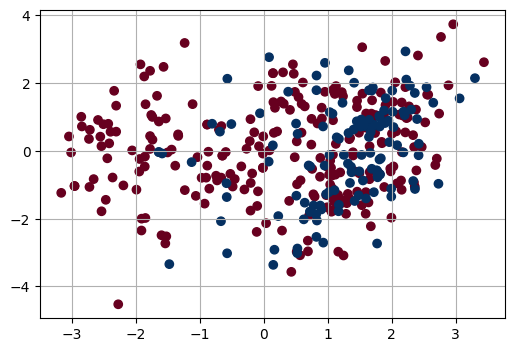

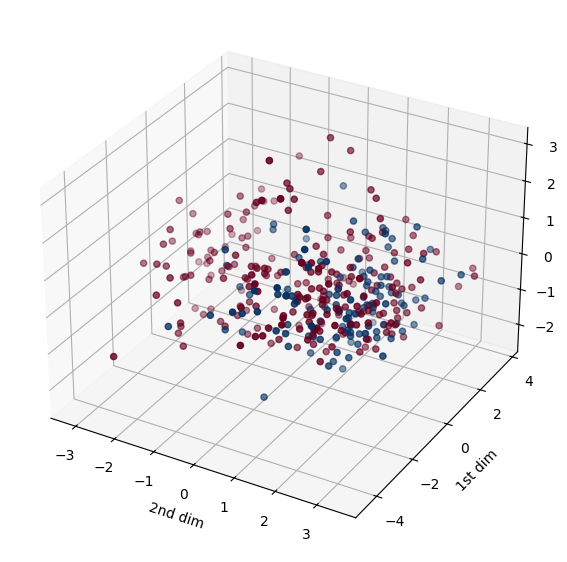

In [75]:
U = plot_PCA(X_undersamp.drop(columns = "Female"), y_undersamp)
X_under_PCA = X_undersamp.drop(columns = "Female") @ U

In [76]:
X_undersamp["Target"] = y_undersamp
X_undersamp.head()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,AR,BilRatio,Female,Target
0,-0.502,-0.795,-0.698,-0.620,-0.435,-0.388,-0.795,-0.652,-0.459,-0.459,0,0
1,0.604,-0.538,-0.698,-0.461,-0.577,-0.607,-0.511,-0.527,-0.459,-0.927,0,0
2,-0.871,-0.658,-0.698,-0.845,-0.794,-1.237,-0.416,-0.150,0.212,-0.722,1,0
3,-1.424,-0.658,-0.698,-0.375,-0.855,-0.690,0.341,0.980,1.220,-0.722,0,0
4,0.174,-0.658,-0.698,-0.953,-0.577,-0.829,1.003,0.980,0.212,-0.722,1,0


In [77]:
X_undersamp.to_csv('undersampled_train.csv', index = False, header = False)
X_undersamp.columns

Index(['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'AR',
       'BilRatio', 'Female', 'Target'],
      dtype='object')